# **Feature Engineering**

This notebook will focus on feature engineering.

Deciding on target:

We will pick future_vol_10 as our target.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
import seaborn as sns

In [26]:
prices = pd.read_csv("C:/Users/jungn/OneDrive/Documents/Projects/Market-Volatility-Prediction/data/spy_eda.csv", index_col=0, parse_dates=True)

C:\Users\jungn\AppData\Local\Temp\ipykernel_18128\3325194594.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  prices = pd.read_csv("C:/Users/jungn/OneDrive/Documents/Projects/Market-Volatility-Prediction/data/spy_eda.csv", index_col=0, parse_dates=True)


In [27]:
prices

,Open,High,Low,Close,Volume,log_return,future_vol_5,future_vol_10,future_vol_20
Price,,,,,,,,,
Ticker,SPY,SPY,SPY,SPY,SPY,NaN,NaN,NaN,NaN
Date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-02,170.47258874432092,170.88559529706598,168.65534982907482,169.6878662109375,121465900,-0.000535,0.015351,0.011903,0.011045
2015-01-05,168.6470660413276,168.8122661140158,166.3177160273211,166.6233367919922,169632600,-0.018225,0.012987,0.010447,0.010748
2015-01-06,166.9289650053605,167.44935723130908,164.26094653071848,165.05392456054688,209151400,-0.009464,0.011958,0.009956,0.010537
...,...,...,...,...,...,...,...,...,...
2025-12-24,684.313382495532,687.1781631452748,684.164151137988,686.7305297851562,39445600,0.003512,0.003566,0.004751,0.006696
2025-12-26,686.989161229118,688.0037280321676,685.6264081645946,686.660888671875,41613300,-0.000101,0.005342,0.004756,0.006749
2025-12-29,683.9055083361335,685.5567672531378,682.4433081832867,684.2138671875,62559500,-0.003570,0.005762,0.004623,0.006687


In [28]:
prices10 = prices.drop(["future_vol_5", "future_vol_20"], axis = 1) #drop columns we don't need

Now we will add some more features to better predict volatility:

**Return based features**

We will add rolling returns, which tell the model: "Has the market recently moved a lot?"

In [29]:
prices10["return_5d"] = prices10["log_return"].rolling(5).sum()
prices10["return_10d"] = prices10["log_return"].rolling(10).sum()
prices10["return_20d"] = prices10["log_return"].rolling(20).sum()

**Volatility Features**

"How volatile has the market been recently?"

In [30]:
prices10["vol_5"] = prices10["log_return"].rolling(5).std()
prices10["vol_10"] = prices10["log_return"].rolling(10).std()
prices10["vol_20"] = prices10["log_return"].rolling(20).std()

**Price range features**

Large intraday ranges often precede higher volatility.

In [31]:
cols = ["Open", "High", "Low", "Close", "Volume"]

prices10[cols] = prices10[cols].apply(
    pd.to_numeric,
    errors="coerce"
)

In [32]:
prices10["hl_range"] = (
    prices10["High"] - prices10["Low"]
) / prices10["Close"]

In [33]:
prices10["oc_range"] = (prices10["Close"] - prices10["Open"]) / prices10["Open"]

Measures the strength of the daily move.

**Volume Features**

Volume often spikes before volatility.

In [34]:
prices10["vol_change"] = prices10["Volume"].pct_change() #Volume change

In [35]:
prices10["vol_ratio"] = (prices10["Volume"] /prices10["Volume"].rolling(20).mean()) #relative volume ie "is today's volume unusually high?"

In [36]:
prices10.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2768 entries, Ticker to 2025-12-31
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Open           2766 non-null   float64
 1   High           2766 non-null   float64
 2   Low            2766 non-null   float64
 3   Close          2766 non-null   float64
 4   Volume         2766 non-null   float64
 5   log_return     2766 non-null   float64
 6   future_vol_10  2766 non-null   float64
 7   return_5d      2762 non-null   float64
 8   return_10d     2757 non-null   float64
 9   return_20d     2747 non-null   float64
 10  vol_5          2762 non-null   float64
 11  vol_10         2757 non-null   float64
 12  vol_20         2747 non-null   float64
 13  hl_range       2766 non-null   float64
 14  oc_range       2766 non-null   float64
 15  vol_change     2765 non-null   float64
 16  vol_ratio      2747 non-null   float64
dtypes: float64(17)
memory usage: 389.2+ KB


In [37]:
prices10.isna().sum()

Open              2
High              2
Low               2
Close             2
Volume            2
log_return        2
future_vol_10     2
return_5d         6
return_10d       11
return_20d       21
vol_5             6
vol_10           11
vol_20           21
hl_range          2
oc_range          2
vol_change        3
vol_ratio        21
dtype: int64

In [38]:
prices10 = prices10.dropna()

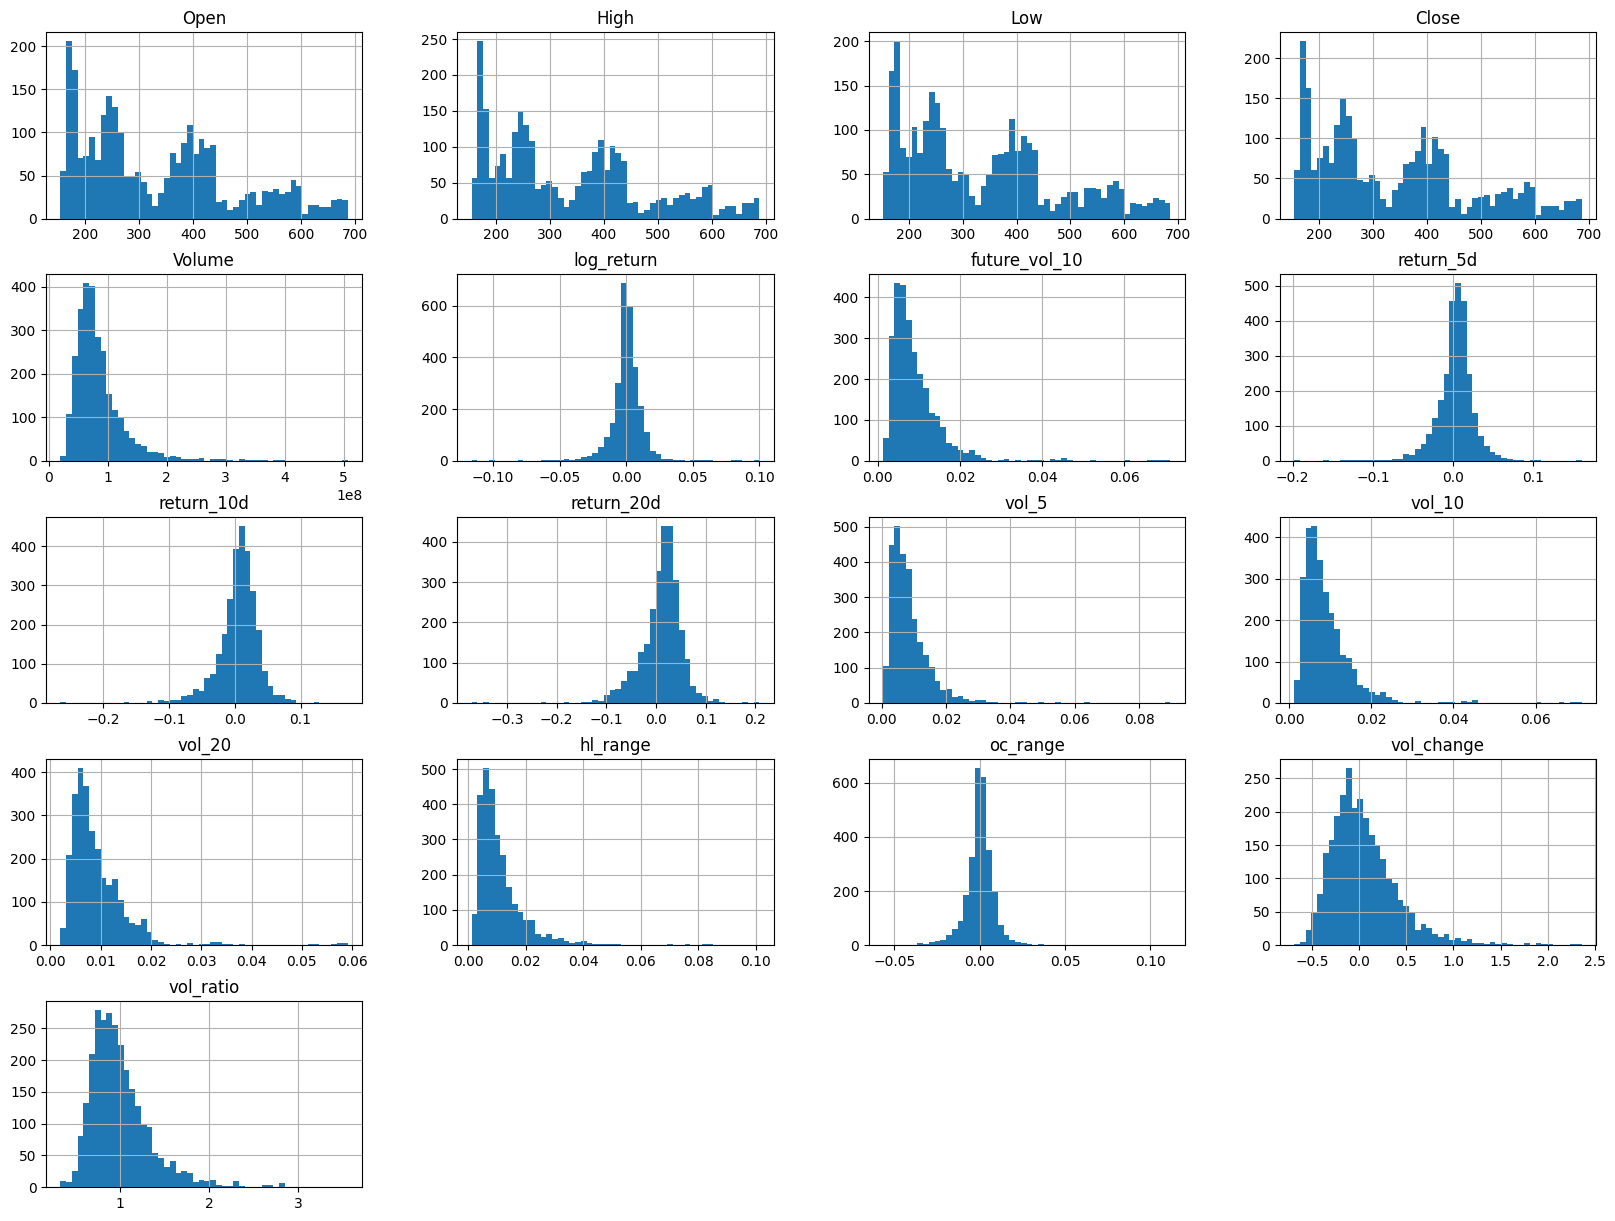

In [39]:
prices10.hist(bins = 50, figsize=(20,15))
plt.show()

We see lots of skewed histograms which might need some scaling depending on which model we choose to use.

### **Creating the test set**

For the test set, we will use data from 2026-01-01 to 2026-06-01

In [40]:
test_set = yf.download("SPY", start = "2025-12-24", end = "2026-06-30")

[*********************100%***********************]  1 of 1 completed


In [41]:
test_set["log_return"] = np.log(test_set["Close"] / test_set["Close"].shift(1))

In [42]:
test_set["future_vol_10"] = (test_set["log_return"].rolling(10).std().shift(-10))

In [43]:
test_set = test_set[
    (test_set.index >= "2026-01-01") & (test_set.index <= "2026-06-01")
]

In [44]:
test_set

Price,Close,High,Low,Open,Volume,log_return,future_vol_10
Ticker,SPY,SPY,SPY,SPY,SPY,,
Date,,,,,,,
2026-01-02,679.558594,683.239047,676.226327,682.085206,89377200,0.001831,0.004173
2026-01-05,684.084534,685.785516,682.751651,682.910779,71927200,0.006638,0.007665
2026-01-06,688.152954,688.660268,684.144289,684.293460,69273800,0.005930,0.008424
2026-01-07,685.934753,690.291605,685.676118,688.530942,75588300,-0.003229,0.008590
2026-01-08,685.865112,686.969230,683.855771,685.178757,64019200,-0.000102,0.008591
...,...,...,...,...,...,...,...
2026-05-26,748.661316,750.197337,746.446989,748.082789,41123600,0.006617,0.009273
2026-05-27,748.531616,749.449235,746.297321,748.950520,42106300,-0.000173,0.010244


In [45]:
test_set["return_5d"] = test_set["log_return"].rolling(5).sum()
test_set["return_10d"] = test_set["log_return"].rolling(10).sum()
test_set["return_20d"] = test_set["log_return"].rolling(20).sum()

In [46]:
test_set["vol_5"] = test_set["log_return"].rolling(5).std()
test_set["vol_10"] = test_set["log_return"].rolling(10).std()
test_set["vol_20"] = test_set["log_return"].rolling(20).std()

In [47]:
cols = ["Open", "High", "Low", "Close", "Volume"]

test_set[cols] = test_set[cols].apply(
    pd.to_numeric,
    errors="coerce"
)

In [48]:
test_set["hl_range"] = (
    test_set["High"] - test_set["Low"]
) / test_set["Close"]

In [49]:
test_set["oc_range"] = (test_set["Close"] - test_set["Open"]) / test_set["Open"]

In [50]:
test_set["vol_change"] = test_set["Volume"].pct_change() #Volume change

In [51]:
test_set["vol_ratio"] = (test_set["Volume"] /test_set["Volume"].rolling(20).mean()) #relative volume ie "is today's volume unusually high?"

In [52]:
test_set.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 103 entries, 2026-01-02 to 2026-06-01
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, SPY)       103 non-null    float64
 1   (High, SPY)        103 non-null    float64
 2   (Low, SPY)         103 non-null    float64
 3   (Open, SPY)        103 non-null    float64
 4   (Volume, SPY)      103 non-null    int64  
 5   (log_return, )     103 non-null    float64
 6   (future_vol_10, )  103 non-null    float64
 7   (return_5d, )      99 non-null     float64
 8   (return_10d, )     94 non-null     float64
 9   (return_20d, )     84 non-null     float64
 10  (vol_5, )          99 non-null     float64
 11  (vol_10, )         94 non-null     float64
 12  (vol_20, )         84 non-null     float64
 13  (hl_range, )       103 non-null    float64
 14  (oc_range, )       103 non-null    float64
 15  (vol_change, )     102 non-null    float64
 16  (vol_ra

In [53]:
test_set.isna().sum()

Price          Ticker
Close          SPY        0
High           SPY        0
Low            SPY        0
Open           SPY        0
Volume         SPY        0
log_return                0
future_vol_10             0
return_5d                 4
return_10d                9
return_20d               19
vol_5                     4
vol_10                    9
vol_20                   19
hl_range                  0
oc_range                  0
vol_change                1
vol_ratio                19
dtype: int64

In [54]:
test_set = test_set.dropna()

In [55]:
test_set

Price,Close,High,Low,Open,Volume,log_return,future_vol_10,return_5d,return_10d,return_20d,vol_5,vol_10,vol_20,hl_range,oc_range,vol_change,vol_ratio
Ticker,SPY,SPY,SPY,SPY,SPY,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,
2026-01-30,688.312073,690.540283,683.487735,688.133032,101835100,-0.002987,0.009946,0.003968,-0.000390,0.014630,0.003578,0.008413,0.006492,0.010246,0.000260,0.044610,1.272511
2026-02-02,691.733948,693.245932,685.775621,685.934810,79286500,0.004959,0.009759,0.003861,0.005407,0.017758,0.003546,0.008550,0.006558,0.010799,0.008454,-0.221423,0.997034
2026-02-03,685.885010,693.275726,680.414084,692.529690,107904600,-0.008491,0.009669,-0.008606,0.017483,0.002628,0.004867,0.005572,0.006730,0.018752,-0.009595,0.360945,1.326893
2026-02-04,682.562683,687.794888,678.156108,686.700666,105204600,-0.004856,0.009582,-0.013361,0.001152,-0.008157,0.004936,0.004735,0.006673,0.014121,-0.006026,-0.025022,1.265729
2026-02-05,674.037964,680.075884,672.217621,677.340421,113610800,-0.012568,0.008763,-0.023943,-0.016626,-0.017496,0.006567,0.005822,0.007187,0.011658,-0.004876,0.079903,1.336301
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-26,748.661316,750.197337,746.446989,748.082789,41123600,0.006617,0.009273,0.016035,0.015156,0.048339,0.006331,0.006920,0.006556,0.005009,0.000773,-0.015287,0.857988
2026-05-27,748.531616,749.449235,746.297321,748.950520,42106300,-0.000173,0.010244,0.022545,0.016499,0.053044,0.004045,0.006868,0.006362,0.004211,-0.000559,0.023896,0.879419


In [56]:
test_set.to_csv("C:/Users/jungn/OneDrive/Documents/Projects/Market-Volatility-Prediction/data/test_set.csv")

### **Checking for correlation**

Here we will check which features are correlated with the target.

<Axes: >

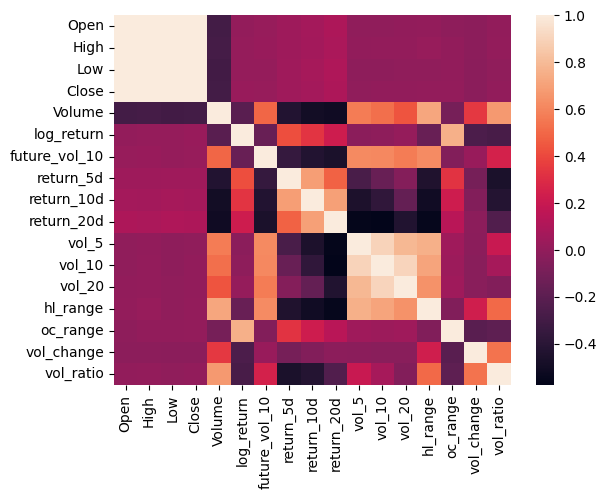

In [22]:
corr_matrix = prices10.corr(numeric_only=True)

sns.heatmap(corr_matrix)

It seems like vol_5, vol_10, vol_20 are reasonalbly correlated with future_vol_10. In other words, recent volatility is correlated with future volatility (good sign).

In [23]:
prices10.to_csv("C:/Users/jungn/OneDrive/Documents/Projects/Market-Volatility-Prediction/data/prices10.csv")

PermissionError: [Errno 13] Permission denied: 'C:/Users/jungn/OneDrive/Documents/Projects/Market-Volatility-Prediction/data/prices10.csv'